# Analytic validation with one point lens

For an isolated point lens with Einstein radius $\theta_E$, the point-source magnification is $\mu(u)=(u^2+2)/[u\sqrt{u^2+4}]$. Its critical curve is the circle $|\boldsymbol{\theta}|=\theta_E$, and the complete circle maps to the single point caustic $\boldsymbol{\beta}=0$. The point-like caustic is therefore physical, not a plotting failure. We show both planes over their full fields rather than magnifying numerical scatter around that point.

The CUDA path uses the standard static $10^7$-ray, $k=1$, $r=2$, $v=4$ IPM configuration. This checks ray tracing, IPM accumulation, analytic Jacobians, marching squares, and critical-curve mapping against a closed-form lens.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.collections import LineCollection
import numpy as np
import torch
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
use_cuda = torch.cuda.is_available()
runtime = mc.RuntimeConfig(device='cuda' if use_cuda else 'cpu', backend=mc.Backend.TRITON if use_cuda else mc.Backend.TORCH_EAGER, strict_backend=use_cuda, dtype='float32')
map_resolution, rays, det_resolution = (1024, 10_000_000, 2049) if use_cuda else (128, 65_536, 513)
source_grid = mc.PlaneGrid((map_resolution, map_resolution), (4.0, 4.0))
system = mc.MicrolensingSystem(
    macro=mc.MacroLens(0.0, 0.0),
    distances=mc.LensingDistances(1.0e25, 2.0e25, 1.0e25),
    stars=mc.PointMassField(torch.tensor([0.0]), torch.tensor([0.0]), mass_solar=torch.tensor([0.07958])),
    source_grid=source_grid, lens_region=mc.PlaneRegion((6.0, 6.0)), runtime=runtime,
)
simulation = system.realize().simulation  # advanced analytic-caustic validation below
print('device:', simulation.runtime.device, 'backend:', simulation.runtime.backend.value, 'rays:', f'{rays:,}')

device: cuda backend: triton rays: 10,000,000


In [2]:
magnification = system.magnification_map(rays=rays)
x, y = source_grid.mesh(device=magnification.values.device, dtype=magnification.values.dtype)
u = torch.sqrt(x.square() + y.square())
analytic = (u.square() + 2.0) / (u * torch.sqrt(u.square() + 4.0))
audit = (u > 0.12) & (u < 1.8)
relative = ((magnification.values[audit] - analytic[audit]).abs() / analytic[audit]).detach().cpu().numpy()
residual_mmag = (-2500.0 * torch.log10(torch.clamp(magnification.values / analytic, min=1e-12))).detach().cpu().numpy()
print(f'median relative error={np.median(relative):.3e}; 95th percentile={np.quantile(relative, 0.95):.3e}')

median relative error=3.167e-05; 95th percentile=9.929e-05


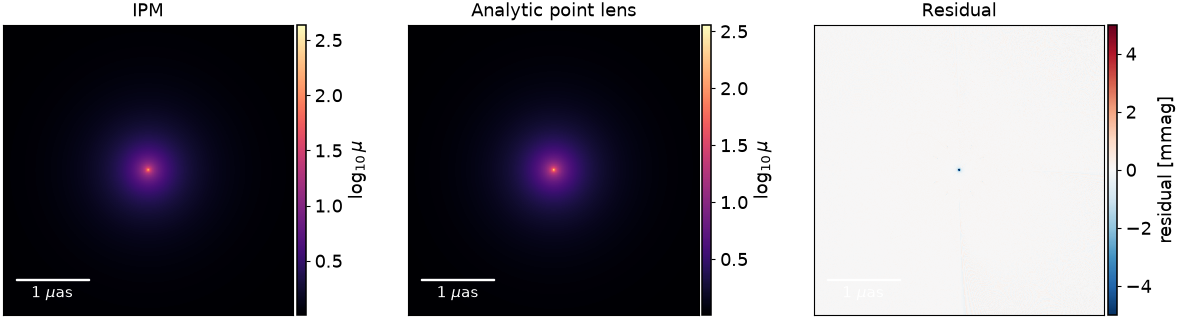

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11.6, 3.75))
extent = source_grid.bounds_uas
images = [np.log10(magnification.values.detach().cpu().numpy()), np.log10(analytic.detach().cpu().numpy()), residual_mmag]
titles = ('IPM', 'Analytic point lens', 'Residual')
labels = (r'$\log_{10}\mu$', r'$\log_{10}\mu$', 'residual [mmag]')
for index, (ax, image_values, title, label) in enumerate(zip(axes, images, titles, labels)):
    kwargs = {'cmap': 'magma'} if index < 2 else {'cmap': 'RdBu_r', 'norm': TwoSlopeNorm(vcenter=0.0, vmin=-5.0, vmax=5.0)}
    artist = ax.imshow(image_values, origin='lower', extent=extent, interpolation='nearest', **kwargs)
    ax.set_title(title)
    mcp.add_scale_bar(ax, 1.0, label=r'1 $\mu$as', location='lower left', color='white')
    mcp.hide_image_axes(ax)
    mcp.panel_colorbar(fig, ax, artist, label=label, size='3%', pad=0.035)
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.08, top=0.91, wspace=0.34)
plt.show()

critical-circle mean |r-theta_E|=5.193e-05 uas
mapped caustic mean radius=1.066e-06 uas


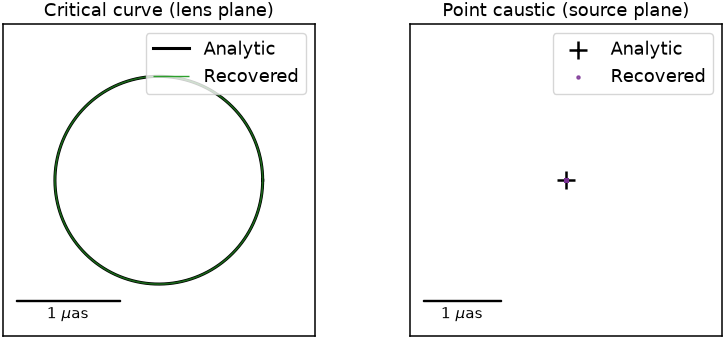

In [4]:
lens_grid = mc.PlaneGrid((det_resolution, det_resolution), (3.0, 3.0))
caustics = simulation.caustics(lens_grid)
critical_segments = caustics.critical_segments_uas.detach().cpu().numpy()
mapped_segments = caustics.caustic_segments_uas.detach().cpu().numpy()
critical_points = critical_segments.reshape(-1, 2)
mapped_points = mapped_segments.reshape(-1, 2)
critical_error = np.abs(np.linalg.norm(critical_points, axis=1) - 1.0)
caustic_radius = np.linalg.norm(mapped_points, axis=1)
print(f'critical-circle mean |r-theta_E|={critical_error.mean():.3e} uas')
print(f'mapped caustic mean radius={caustic_radius.mean():.3e} uas')

angle = np.linspace(0.0, 2.0 * np.pi, 720)
fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.8))
axes[0].plot(np.cos(angle), np.sin(angle), color='black', lw=2.2, label='Analytic')
axes[0].add_collection(LineCollection(critical_segments, colors='#2ca02c', linewidths=1.0, label='Recovered'))
axes[0].set_xlim(-1.5, 1.5); axes[0].set_ylim(-1.5, 1.5)
axes[0].set_title('Critical curve (lens plane)')
axes[0].legend(loc='upper right', frameon=True)
axes[0].set_facecolor('white')
axes[0].set_xticks([]); axes[0].set_yticks([])
mcp.add_scale_bar(axes[0], 1.0, label=r'1 $\mu$as', location='lower left', color='black')

# An isolated point lens genuinely has a zero-dimensional source-plane
# caustic. Show it on the full magnification-map field; a numerical zoom would
# visually exaggerate its few-microarcsecond discretization error.
axes[1].scatter([0.0], [0.0], marker='+', s=150, linewidths=1.8, color='black', label='Analytic')
axes[1].scatter(mapped_points[:, 0], mapped_points[:, 1], s=5, color='#7b3294', alpha=0.8, label='Recovered')
axes[1].set_xlim(-2.0, 2.0); axes[1].set_ylim(-2.0, 2.0)
axes[1].set_title('Point caustic (source plane)')
axes[1].legend(loc='upper right', frameon=True)
axes[1].set_facecolor('white')
axes[1].set_xticks([]); axes[1].set_yticks([])
mcp.add_scale_bar(axes[1], 1.0, label=r'1 $\mu$as', location='lower left', color='black')
for ax in axes:
    ax.set_aspect('equal')
    for spine in ax.spines.values():
        spine.set_visible(True)
fig.subplots_adjust(left=0.04, right=0.98, bottom=0.08, top=0.90, wspace=0.18)
plt.show()